In [1]:
!ls 

draw_distr_plots.ipynb proc_configs.ipynb     processed
plots                  proc_mmarco.ipynb      raw


In [10]:
import os
os.makedirs('plots_beir', exist_ok=True)

In [12]:
# BEIR uses a smaller chunks size
CHUNK_SIZE=128

In [5]:
PART_DICT={k:[k] for k in 'beir_nfcorpus beir_scidocs beir_scifact beir_trec_covid beir_webis_touche2020_v2 wikipedia_beir_nq'.split()}
PART_DICT.keys(), PART_DICT

(dict_keys(['beir_nfcorpus', 'beir_scidocs', 'beir_scifact', 'beir_trec_covid', 'beir_webis_touche2020_v2', 'wikipedia_beir_nq']),
 {'beir_nfcorpus': ['beir_nfcorpus'],
  'beir_scidocs': ['beir_scidocs'],
  'beir_scifact': ['beir_scifact'],
  'beir_trec_covid': ['beir_trec_covid'],
  'beir_webis_touche2020_v2': ['beir_webis_touche2020_v2'],
  'wikipedia_beir_nq': ['wikipedia_beir_nq']})

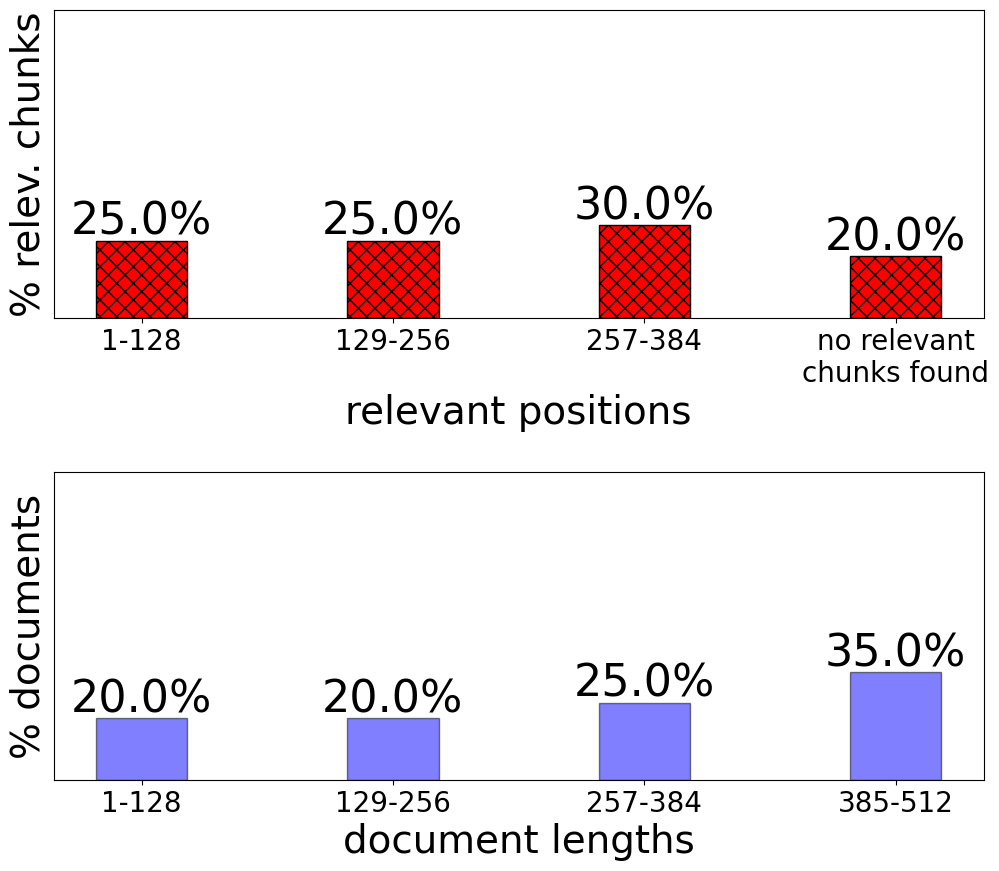

In [6]:
from utils import plot_percentage_bars_ver3

# Example usage
match_start_arr = [0, 1, 2, -1, 2, 2, 1, 0, -1, 0, 1, -1, 2, 2, 2, 0, 1, 1, -1, 0]
doc_len_arr = [0, 1, 2, 2, 3, 3, 1, 0, 2, 1, 3, 3, 3, 0, 0, 1, 2, 2, 3, 3]
max_value = 3

# Example with saving
plot_percentage_bars_ver3(match_start_arr, doc_len_arr, max_value, chunk_size=CHUNK_SIZE)

In [11]:
import json
import os
from tqdm.auto import tqdm

from collections import defaultdict


for idx, (part_key, part_name_arr) in enumerate(PART_DICT.items()):

    doc_lens_dict = defaultdict(int)
    match_start_dict = defaultdict(int)
    for part_name in part_name_arr:
        for k, v in json.load(open(f'processed/{part_name}/doc_lens_dict.json')):
            if type(k) == list:
                k = tuple(k)
            doc_lens_dict[k] += v
        for k, v in json.load(open(f'processed/{part_name}/match_start_dict.json')):
            if type(k) == list:
                k = tuple(k)
            match_start_dict[k] += v

    # We don't do this any more
    # We add one to all non-negative because we look at the positions where a relevant chunk ends.
    # We don't change -1 b/c it has special meaning: no relevant are found
    #match_start_adj_arr = list(map(lambda e: e + 1 if e >= 0 else e, match_start_dict.values()))
    
    plot_percentage_bars_ver3(list(match_start_dict.values()),
                            list(doc_lens_dict.values()), max_value=4, chunk_size=CHUNK_SIZE, 
                            figure_name=f'plots_beir/{part_key}')

Figure saved as plots_beir/beir_nfcorpus.png
Figure saved as plots_beir/beir_scidocs.png
Figure saved as plots_beir/beir_scifact.png
Figure saved as plots_beir/beir_trec_covid.png
Figure saved as plots_beir/beir_webis_touche2020_v2.png
Figure saved as plots_beir/wikipedia_beir_nq.png


In [ ]:
#list(match_start_dict.values())